# WDF Curve Covariance Demo

This notebook demonstrates the OTC curve pricer for the WDF curve family:
- Load and visualize historical WDF curves
- Compute and display covariance matrix
- Show eigen-decomposition (PC1, PC2 = level, slope)
- Simulate scenarios: 1 anchor vs 3 anchors
- Visualize implied curves with confidence bands
- Compare recency effect (fresh vs stale anchor)

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add src to path
project_root = Path().resolve().parent
sys.path.insert(0, str(project_root / "src"))

from otc_pricer.parsing import extract_curve_families
from otc_pricer.covariance import get_covariance, compute_daily_returns, load_historical_data
from otc_pricer.inference import (
    compute_posterior,
    compute_implied_curve,
    compute_confidence_bands
)

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## 1. Load Historical Data and Visualize WDF Curves

In [3]:
# Load historical data
data_path = project_root / "data_.csv"
curve_family = "wdf"

# Extract available curve families
families = extract_curve_families(str(data_path))
print(f"Available curve families: {list(families.keys())[:10]}...")  # Show first 10
print(f"\nWDF tenors: {families.get('wdf', [])}")

# Load WDF historical data
curve_df, tenors = load_historical_data(str(data_path), curve_family)
print(f"\nLoaded {len(curve_df)} days of data for {len(tenors)} tenors")
print(f"Date range: {curve_df.index.min()} to {curve_df.index.max()}")

Available curve families: ['clbr', 'htt', 'wdf', 'houbr', 'crossarb', 'dfl', 'tdl', 'bod', 'yv_dbi', 'brn_dbi']...

WDF tenors: ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15']

Loaded 1041 days of data for 15 tenors
Date range: 2022-01-03 00:00:00 to 2025-12-25 00:00:00


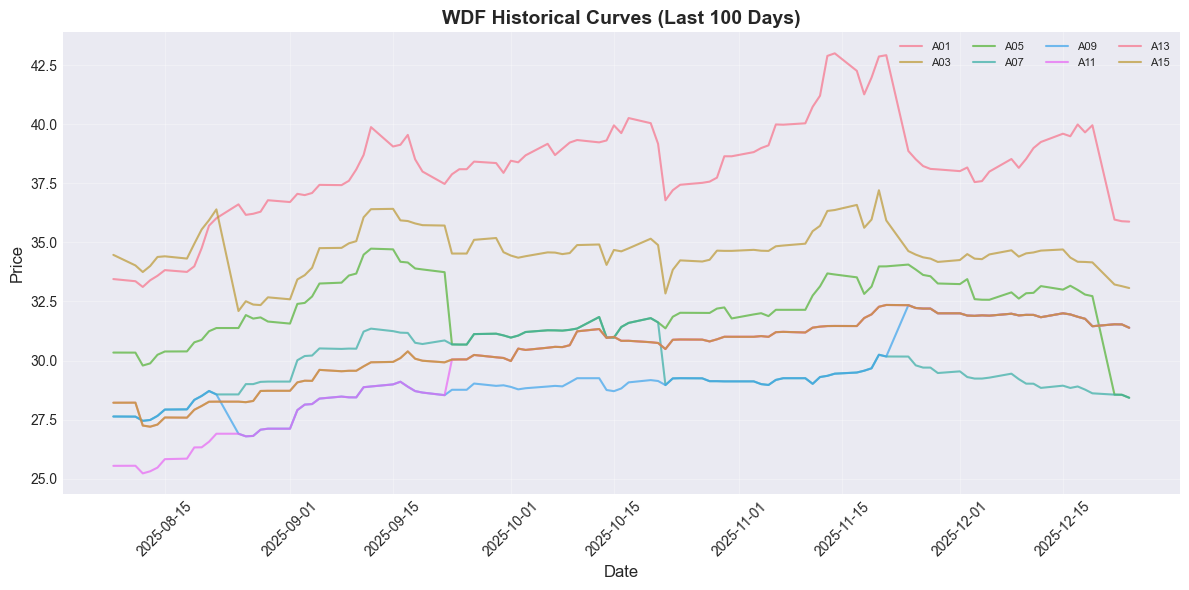

In [4]:
# Visualize historical curves (last 100 days)
fig, ax = plt.subplots(figsize=(12, 6))
recent_data = curve_df.tail(100)

for tenor in tenors[::2]:  # Show every other tenor for clarity
    ax.plot(recent_data.index, recent_data[tenor], label=tenor, alpha=0.7, linewidth=1.5)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Price', fontsize=12)
ax.set_title(f'WDF Historical Curves (Last 100 Days)', fontsize=14, fontweight='bold')
ax.legend(ncol=4, fontsize=8)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Compute and Display Covariance Matrix

In [5]:
# Compute covariance
cov, tenors = get_covariance(
    str(data_path),
    curve_family,
    window_days=252,
    shrink_lambda=0.1,
    cache_dir=str(project_root / "data" / "cache")
)

print(f"Covariance matrix shape: {cov.shape}")
print(f"Condition number: {np.linalg.cond(cov):.2e}")

# Check positive semi-definite
eigenvals = np.linalg.eigvals(cov)
print(f"Eigenvalue range: [{np.min(eigenvals):.4f}, {np.max(eigenvals):.4f}]")
print(f"All eigenvalues >= 0: {np.all(eigenvals >= -1e-8)}")

Computing covariance for wdf (window=252 days)...
Cached covariance to \\smartconnectdvt\DV_ENERGY\Other Stuff\Nick\My Projects\Coding\otc_curve_pricer_2\data\cache\cov_wdf_252.pkl
Covariance matrix shape: (15, 15)
Condition number: 8.93e+01
Eigenvalue range: [0.0149, 1.3287]
All eigenvalues >= 0: True


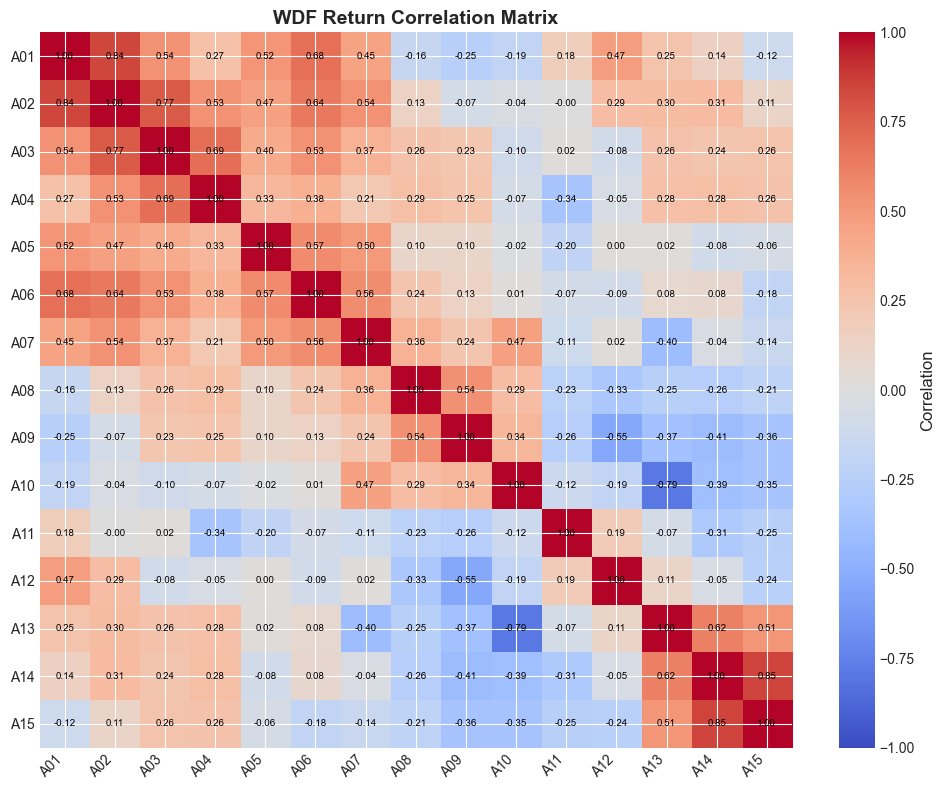

In [6]:
# Visualize covariance matrix as heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = np.corrcoef(cov)  # Convert to correlation for better visualization
im = ax.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)

ax.set_xticks(range(len(tenors)))
ax.set_yticks(range(len(tenors)))
ax.set_xticklabels(tenors, rotation=45, ha='right')
ax.set_yticklabels(tenors)
ax.set_title('WDF Return Correlation Matrix', fontsize=14, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Correlation', fontsize=12)

# Add text annotations for correlation values
for i in range(len(tenors)):
    for j in range(len(tenors)):
        text = ax.text(j, i, f'{corr_matrix[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=7)

plt.tight_layout()
plt.show()

## 3. Eigen-decomposition (Principal Components)

PC1 typically represents "level" (parallel shift), PC2 represents "slope" (steepening/flattening).

In [7]:
# Eigen-decomposition
eigenvals, eigenvecs = np.linalg.eigh(cov)
# Sort by eigenvalue (descending)
idx = np.argsort(eigenvals)[::-1]
eigenvals = eigenvals[idx]
eigenvecs = eigenvecs[:, idx]

# Explained variance
explained_var = eigenvals / np.sum(eigenvals) * 100

print("Top 5 Principal Components:")
print(f"PC1 explains {explained_var[0]:.1f}% of variance")
print(f"PC2 explains {explained_var[1]:.1f}% of variance")
print(f"PC3 explains {explained_var[2]:.1f}% of variance")
print(f"PC4 explains {explained_var[3]:.1f}% of variance")
print(f"PC5 explains {explained_var[4]:.1f}% of variance")

Top 5 Principal Components:
PC1 explains 42.2% of variance
PC2 explains 11.7% of variance
PC3 explains 8.8% of variance
PC4 explains 6.8% of variance
PC5 explains 5.9% of variance


C:\Users\nazinge\AppData\Local\Temp\ipykernel_130856\2468171136.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(tenors, rotation=45)
C:\Users\nazinge\AppData\Local\Temp\ipykernel_130856\2468171136.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(tenors, rotation=45)


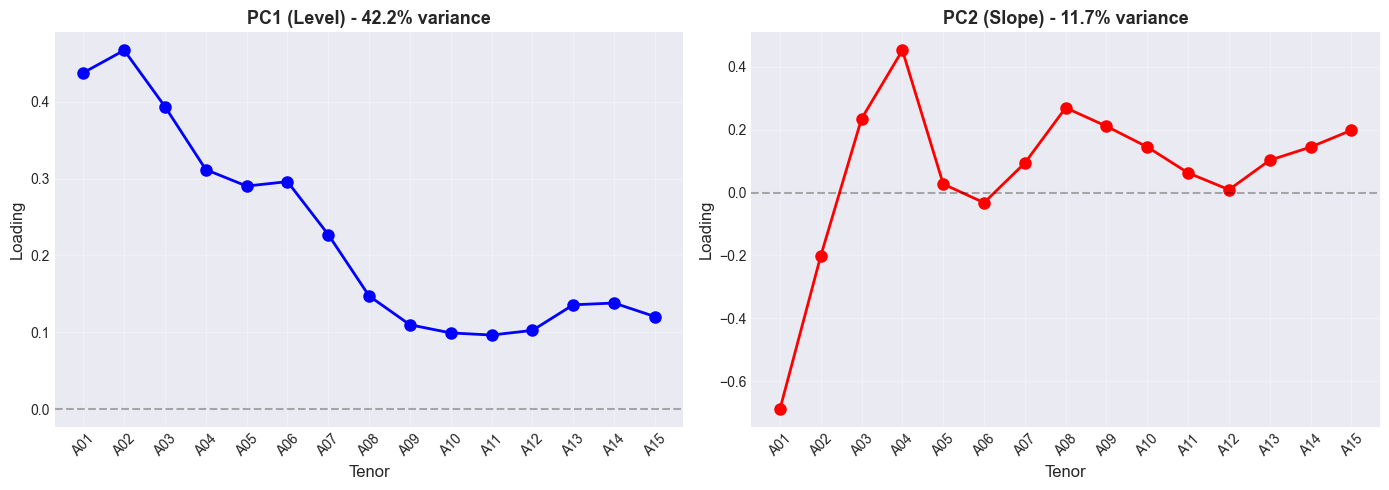

In [8]:
# Visualize PC1 (level) and PC2 (slope)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# PC1 - Level
ax1.plot(tenors, eigenvecs[:, 0], 'o-', linewidth=2, markersize=8, color='blue')
ax1.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax1.set_xlabel('Tenor', fontsize=12)
ax1.set_ylabel('Loading', fontsize=12)
ax1.set_title(f'PC1 (Level) - {explained_var[0]:.1f}% variance', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticklabels(tenors, rotation=45)

# PC2 - Slope
ax2.plot(tenors, eigenvecs[:, 1], 'o-', linewidth=2, markersize=8, color='red')
ax2.axhline(y=0, color='black', linestyle='--', alpha=0.3)
ax2.set_xlabel('Tenor', fontsize=12)
ax2.set_ylabel('Loading', fontsize=12)
ax2.set_title(f'PC2 (Slope) - {explained_var[1]:.1f}% variance', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticklabels(tenors, rotation=45)

plt.tight_layout()
plt.show()

## 4. Simulate Scenarios: 1 Anchor vs 3 Anchors

In [37]:
# Setup base curve (flat at 180)
base_curve = {tenor: 180.0 for tenor in tenors}

# Scenario 1: Single anchor at A03
anchors_1 = [
    {
        'month': 'A03',
        'value': 190.0,
        'age_minutes': 0  # Fresh (30 minutes old)
    }
]

# Scenario 2: Three anchors
anchors_3 = [
    {
        'month': 'A02',
        'value': 190.0,
        'age_minutes': 60
    },
    {
        'month': 'A05',
        'value': 185.0,
        'age_minutes': 45
    },
    {
        'month': 'A10',
        'value': 175.0,
        'age_minutes': 90
    }
]

# Inference parameters
sigma_min = 0.01
sigma_max = 5.0
half_life_min = 100000
z = 1.5

# Run inference for both scenarios
shock_1, cov_post_1 = compute_posterior(
    cov, anchors_1, base_curve, tenors,
    sigma_min, sigma_max, half_life_min
)
implied_1 = compute_implied_curve(base_curve, shock_1, tenors)
bands_1 = compute_confidence_bands(cov_post_1, z)

shock_3, cov_post_3 = compute_posterior(
    cov, anchors_3, base_curve, tenors,
    sigma_min, sigma_max, half_life_min
)
implied_3 = compute_implied_curve(base_curve, shock_3, tenors)
bands_3 = compute_confidence_bands(cov_post_3, z)

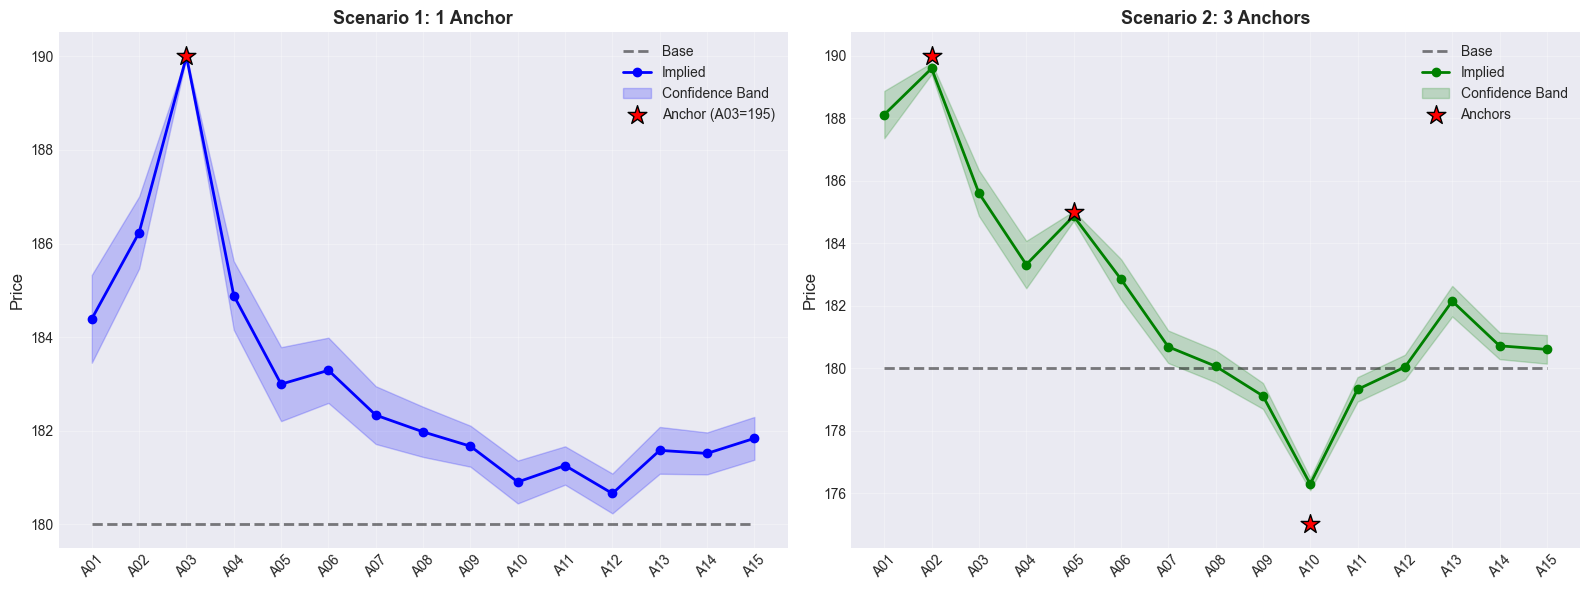


Band Width Comparison:
1 Anchor - Average band: 0.55, Max: 0.94
3 Anchors - Average band: 0.47, Max: 0.76

3 anchors reduce uncertainty by 14.6% on average


In [38]:
# Visualize both scenarios
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Scenario 1: 1 anchor
x_pos = range(len(tenors))
base_vals = [base_curve[t] for t in tenors]
implied_vals_1 = [implied_1[t] for t in tenors]
upper_1 = [implied_vals_1[i] + bands_1[i] for i in range(len(tenors))]
lower_1 = [implied_vals_1[i] - bands_1[i] for i in range(len(tenors))]

ax1.plot(x_pos, base_vals, 'k--', label='Base', linewidth=2, alpha=0.5)
ax1.plot(x_pos, implied_vals_1, 'b-o', label='Implied', linewidth=2, markersize=6)
ax1.fill_between(x_pos, lower_1, upper_1, alpha=0.2, color='blue', label='Confidence Band')
# Mark anchor
anchor_idx_1 = tenors.index('A03')
ax1.scatter([anchor_idx_1], [190.0], s=200, color='red', marker='*', 
           zorder=5, label='Anchor (A03=195)', edgecolors='black', linewidths=1)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(tenors, rotation=45)
ax1.set_ylabel('Price', fontsize=12)
ax1.set_title('Scenario 1: 1 Anchor', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Scenario 2: 3 anchors
implied_vals_3 = [implied_3[t] for t in tenors]
upper_3 = [implied_vals_3[i] + bands_3[i] for i in range(len(tenors))]
lower_3 = [implied_vals_3[i] - bands_3[i] for i in range(len(tenors))]

ax2.plot(x_pos, base_vals, 'k--', label='Base', linewidth=2, alpha=0.5)
ax2.plot(x_pos, implied_vals_3, 'g-o', label='Implied', linewidth=2, markersize=6)
ax2.fill_between(x_pos, lower_3, upper_3, alpha=0.2, color='green', label='Confidence Band')
# Mark anchors
for anchor in anchors_3:
    anchor_idx = tenors.index(anchor['month'])
    ax2.scatter([anchor_idx], [anchor['value']], s=200, color='red', marker='*',
               zorder=5, edgecolors='black', linewidths=1)
ax2.scatter([], [], s=200, color='red', marker='*', edgecolors='black', 
           linewidths=1, label='Anchors')

ax2.set_xticks(x_pos)
ax2.set_xticklabels(tenors, rotation=45)
ax2.set_ylabel('Price', fontsize=12)
ax2.set_title('Scenario 2: 3 Anchors', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nBand Width Comparison:")
print(f"1 Anchor - Average band: {np.mean(bands_1):.2f}, Max: {np.max(bands_1):.2f}")
print(f"3 Anchors - Average band: {np.mean(bands_3):.2f}, Max: {np.max(bands_3):.2f}")
print(f"\n3 anchors reduce uncertainty by {((1 - np.mean(bands_3)/np.mean(bands_1)) * 100):.1f}% on average")

## 5. Recency Effect: Fresh vs Stale Anchor

In [ ]:
# Same anchor value, different ages
anchor_fresh = [
    {
        'month': 'A05',
        'value': 18.0,
        'age_minutes': 5  # Very fresh (5 minutes)
    }
]

anchor_stale = [
    {
        'month': 'A05',
        'value': 185.0,
        'age_minutes': 480  # Stale (8 hours old)
    }
]

# Run inference
shock_fresh, cov_post_fresh = compute_posterior(
    cov, anchor_fresh, base_curve, tenors,
    sigma_min, sigma_max, half_life_min
)
implied_fresh = compute_implied_curve(base_curve, shock_fresh, tenors)
bands_fresh = compute_confidence_bands(cov_post_fresh, z)

shock_stale, cov_post_stale = compute_posterior(
    cov, anchor_stale, base_curve, tenors,
    sigma_min, sigma_max, half_life_min
)
implied_stale = compute_implied_curve(base_curve, shock_stale, tenors)
bands_stale = compute_confidence_bands(cov_post_stale, z)

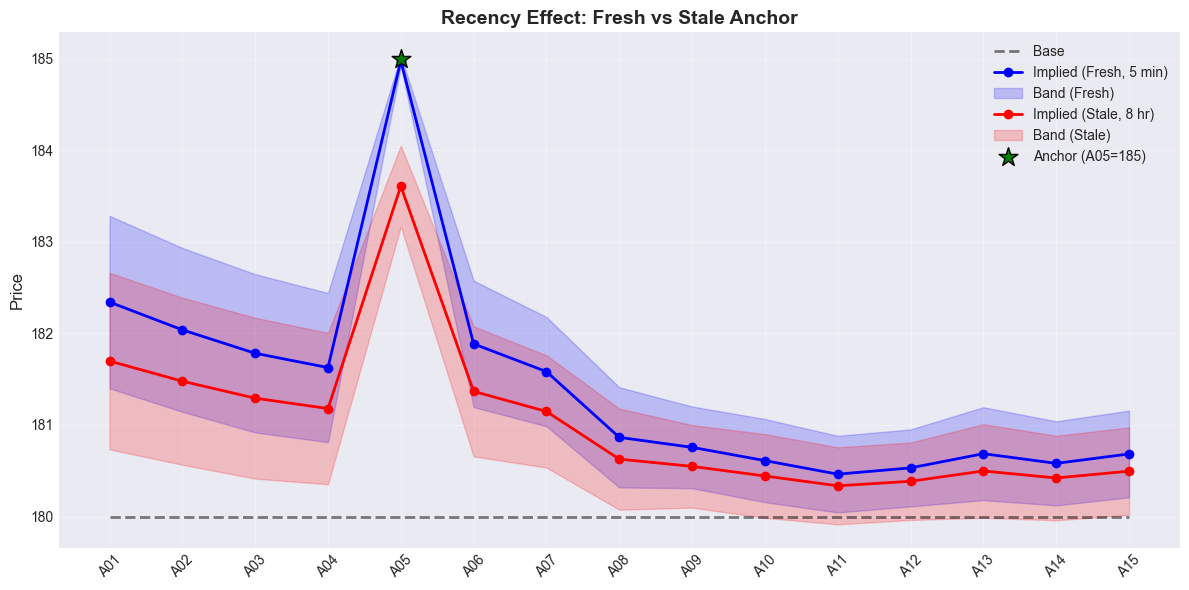


Recency Effect Comparison:
Fresh anchor (5 min) - Average band: 0.57, Max: 0.94
Stale anchor (8 hr)  - Average band: 0.61, Max: 0.96

Stale anchor has 6.0% wider bands on average
This demonstrates that recent anchors provide stronger constraints!


In [40]:
# Visualize recency effect
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = range(len(tenors))
base_vals = [base_curve[t] for t in tenors]
implied_vals_fresh = [implied_fresh[t] for t in tenors]
implied_vals_stale = [implied_stale[t] for t in tenors]

upper_fresh = [implied_vals_fresh[i] + bands_fresh[i] for i in range(len(tenors))]
lower_fresh = [implied_vals_fresh[i] - bands_fresh[i] for i in range(len(tenors))]
upper_stale = [implied_vals_stale[i] + bands_stale[i] for i in range(len(tenors))]
lower_stale = [implied_vals_stale[i] - bands_stale[i] for i in range(len(tenors))]

ax.plot(x_pos, base_vals, 'k--', label='Base', linewidth=2, alpha=0.5)
ax.plot(x_pos, implied_vals_fresh, 'b-o', label='Implied (Fresh, 5 min)', linewidth=2, markersize=6)
ax.fill_between(x_pos, lower_fresh, upper_fresh, alpha=0.2, color='blue', label='Band (Fresh)')
ax.plot(x_pos, implied_vals_stale, 'r-o', label='Implied (Stale, 8 hr)', linewidth=2, markersize=6)
ax.fill_between(x_pos, lower_stale, upper_stale, alpha=0.2, color='red', label='Band (Stale)')

# Mark anchor
anchor_idx = tenors.index('A05')
ax.scatter([anchor_idx], [185.0], s=200, color='green', marker='*',
          zorder=5, label='Anchor (A05=185)', edgecolors='black', linewidths=1)

ax.set_xticks(x_pos)
ax.set_xticklabels(tenors, rotation=45)
ax.set_ylabel('Price', fontsize=12)
ax.set_title('Recency Effect: Fresh vs Stale Anchor', fontsize=14, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print comparison
print("\nRecency Effect Comparison:")
print(f"Fresh anchor (5 min) - Average band: {np.mean(bands_fresh):.2f}, Max: {np.max(bands_fresh):.2f}")
print(f"Stale anchor (8 hr)  - Average band: {np.mean(bands_stale):.2f}, Max: {np.max(bands_stale):.2f}")
print(f"\nStale anchor has {((np.mean(bands_stale)/np.mean(bands_fresh) - 1) * 100):.1f}% wider bands on average")
print(f"This demonstrates that recent anchors provide stronger constraints!")

## Summary

This notebook demonstrated:
1. **Historical Analysis**: Visualized WDF curve evolution over time
2. **Covariance Structure**: Showed how tenors co-move (high correlation for adjacent tenors)
3. **Principal Components**: Identified level (PC1) and slope (PC2) as dominant factors
4. **Multi-Anchor Inference**: More anchors reduce uncertainty significantly
5. **Recency Effect**: Fresh anchors provide tighter constraints than stale ones

The Bayesian framework successfully combines:
- Historical covariance (prior knowledge)
- Partial observations (anchors)
- Recency weighting (confidence decay)

This creates a "senior trader with memory" that makes statistically coherent curve estimates.